In [17]:
import json

In [18]:
#!pip install transformers

In [19]:
import torch
import pandas as pd
import numpy as np

In [20]:
import urllib.request

def getEntries ( url):
    
    request = urllib.request.Request (url   , None, {'User-Agent' : 'test'})
    response = urllib.request.urlopen (request)
    
    return json.loads(response.read())

___
### My Data 

In [86]:
path = "/Users/kazotogbah/Desktop/CapstoneWritting/hmh_data/grade5_teachers_guide_pal_corpus_clean_keywords_sumy_distilroberta34b1dc07f9547647fb90760ba6630e5f92fd7af8e4a0d66a84cc084020f76b2d.pkl" 
teachersGuidePal = pd.read_pickle(path,compression='infer')
teachersGuidePal

,file,page,text,content_type,Skill Title,Skill Description,Skill GUID,Skill Code,strand,strand_description,...,Skill Title_embedded,Skill Description_embedded,strand_embedded,Skill Title_no_periods_embedded,Skill Description_no_periods_embedded,strand_no_periods_embedded,strand_description_no_periods_embedded,skill_description_keywords_embedded,strand_description_keywords_embedded,text_clean_summarized_embedded
0,C:\Users\rdominguez\Documents\Pers\UChicago\Ca...,1.0,MODULE\n˜\nﬁ I will not follow \nwhere the pat...,content,module i will not follow where the path may le...,module i will not follow where the path may le...,nan,nan,module i will not follow where the path may le...,module i will not follow where the path may le...,...,"[0.05007931, 0.119613454, 0.032607853, 0.41877...","[0.05007931, 0.119613454, 0.032607853, 0.41877...","[0.05007931, 0.119613454, 0.032607853, 0.41877...","[0.021318758, 0.13580242, 0.051272195, 0.41786...","[0.021318758, 0.13580242, 0.051272195, 0.41786...","[0.021318758, 0.13580242, 0.051272195, 0.41786...","[0.021318758, 0.13580242, 0.051272195, 0.41786...","[0.28464243, 0.2220484, 0.4422115, 0.0465012, ...","[0.28464243, 0.2220484, 0.4422115, 0.0465012, ...","[0.20862822, -0.033599023, 0.044862866, 0.2881..."
1,C:\Users\rdominguez\Documents\Pers\UChicago\Ca...,2.0,MODULE\n˜\nﬁ I will not follow \nwhere the pat...,content,module i will not follow where the path may le...,module i will not follow where the path may le...,nan,nan,module i will not follow where the path may le...,module i will not follow where the path may le...,...,"[0.05007931, 0.119613454, 0.032607853, 0.41877...","[0.05007931, 0.119613454, 0.032607853, 0.41877...","[0.05007931, 0.119613454, 0.032607853, 0.41877...","[0.021318758, 0.13580242, 0.051272195, 0.41786...","[0.021318758, 0.13580242, 0.051272195, 0.41786...","[0.021318758, 0.13580242, 0.051272195, 0.41786...","[0.021318758, 0.13580242, 0.051272195, 0.41786...","[0.30782643, 0.058543533, 0.16792017, 0.085862...","[0.30782643, 0.058543533, 0.16792017, 0.085862...","[0.16788949, -0.13963626, -0.07024216, 0.53562..."
2,C:\Users\rdominguez\Documents\Pers\UChicago\Ca...,3.0,˜˚˛˝˙ˆˇ˘˝\n\nˆˇ\nThe words in the chart will h...,content,the words in the chart will help you talk and ...,the words in the chart will help you talk and ...,nan,nan,the words in the chart will help you talk and ...,the words in the chart will help you talk and ...,...,"[0.24913393, -0.16405915, -0.045558963, -0.163...","[0.24913393, -0.16405915, -0.045558963, -0.163...","[0.24913393, -0.16405915, -0.045558963, -0.163...","[0.2626564, -0.15431736, -0.14201987, -0.11405...","[0.2626564, -0.15431736, -0.14201987, -0.11405...","[0.2626564, -0.15431736, -0.14201987, -0.11405...","[0.2626564, -0.15431736, -0.14201987, -0.11405...","[0.318849, 0.5429922, 0.2398742, -0.08303005, ...","[0.318849, 0.5429922, 0.2398742, -0.08303005, ...","[0.23586863, 0.037411276, 0.0036898185, 0.0774..."
3,C:\Users\rdominguez\Documents\Pers\UChicago\Ca...,4.0,˜˚˛˝˙ˆˇ˘˝\n\nˆˇ\nThe words in the chart will h...,content,the words in the chart will help you talk and ...,the words in the chart will help you talk and ...,nan,nan,the words in the chart will help you talk and ...,the words in the chart will help you talk and ...,...,"[0.24913393, -0.16405915, -0.045558963, -0.163...","[0.24913393, -0.16405915, -0.045558963, -0.163...","[0.24913393, -0.16405915, -0.045558963, -0.163...","[0.2626564, -0.15431736, -0.14201987, -0.11405...","[0.2626564, -0.15431736, -0.14201987, -0.11405...","[0.2626564, -0.15431736, -0.14201987, -0.11405...","[0.2626564, -0.15431736, -0.14201987, -0.11405...","[0.34651068, 0.33815506, 0.31886512, -0.218285...","[0.34651068, 0.33815506, 0.31886512, -0.218285...","[0.13544446, 0.15687963, -0.033667527, -0.0243..."
4,C:\Users\rdominguez\Documents\Pers\UChicago\Ca...,5.0,˜\n˚˛˝˙˜\n\nReasons to \nInvent\nSolve \nProbl...,content,reasons to invent solve problems achieve fame ...,reasons to invent solve problems achi

In [87]:
## collect page content and skill description
import pandas as pd
import numpy as np
pal_skills2 = []
pal_content2 = []
page = -1
for text in teachersGuidePal['content_type']:
    page = page+1
    if teachersGuidePal['content_type'][page]== "content":
        pal_content2.append(teachersGuidePal['Skill Description'][page])
    else:
        pal_skills2.append(teachersGuidePal['Skill Description'][page])

In [88]:
# concatenate question question words
import pandas as pd
import numpy as np
skills_to_Quest = []
skillnum = -1
concat_1 = "How to "
concat_2 = "?"
for skill in pal_skills2:
    skillnum = skillnum+1
    skills_to_Quest.append(concat_1 + pal_skills2[skillnum] + concat_2)
    
skills_to_Quest  

["How to identify an informational text's intended audience while reading and analyze how it affects the author's development of a text?",
 "How to understand that authors write texts for different purposes to inform persuade entertain or share thoughts or feelings and identify author's purpose(s) while reading text?",
 'How to while reading analyze how the author advances the purpose of a text in terms of style and use of text structure language and rhetoric (e.g. formal or informal language figures of speech tone persuasiveness) and evaluate the degree to which the author achieved the purpose of the text?',
 "How to determine the author's perspective and opinions including underlying values and beliefs based on explicit and implicit information while reading text?",
 "How to identify and analyze an author's qualifications to evaluate the author's credibility?",
 "How to while reading evaluate how an author's personal cultural and historical background impacts their purpose for writin

___


In [98]:
skills_to_Quest [2]

'How to while reading analyze how the author advances the purpose of a text in terms of style and use of text structure language and rhetoric (e.g. formal or informal language figures of speech tone persuasiveness) and evaluate the degree to which the author achieved the purpose of the text?'

In [104]:
contexts=[]
questions = []
for i in range(10):
    questions.append(skills_to_Quest[i])
    contexts.append(pal_content2[i])
    i=i+1

questions[9]


"How to while reading compare and contrast how different authors' personal cultural and historical backgrounds impact their purpose for writing and the structure and meaning of the texts they write?"

In [105]:
contexts[5]

'reasons to invent solve problems achieve fame and fortune 14 do not edit changes must be made through file infofl correctionkey=tx a do not edit changes must be made through file infofl correctionkey=tx a 5re_se_m1_km.indd 14 2/26/2018 5 36 29 am make life easier entertain people 15 do not edit changes must be made through file infofl correctionkey=tx a 5re_se_m1_km.indd 15 2/26/2018 5 36 30 am inventors at work 15 do not edit changes must be made through file infofl correctionkey=tx a'

In [106]:
contexts[6]

'my notes e very year our government collects trillions of dollars in taxes. most of the funds pay for programs that keep citizens safe and healthy. other amounts fund programs such as public education. some of the money goes to run the government itself. it s expensive to keep our country running! sadly just a small percentage goes to fund innovation and invention. in recent years the government has spent only a small percentage of the federal budget on scientific and medical research. this is not right! the federal government must spend more money to support inventors and their work. invention is crucial for the economic and social well being of our country. funding inventors improves people s lives creates jobs and helps our nation excel as a leader in science and technology. inventors need government support it s often the case that only the government has the huge funds needed to support truly great innovation. to build a faster computer or transcend the barriers of space travel i

In [110]:
contexts[4]


'reasons to invent solve problems achieve fame and fortune 14 do not edit changes must be made through file infofl correctionkey=tx a do not edit changes must be made through file infofl correctionkey=tx a 5re_se_m1_km.indd 14 2/26/2018 5 36 29 am make life easier entertain people 15 do not edit changes must be made through file infofl correctionkey=tx a 5re_se_m1_km.indd 15 2/26/2018 5 36 30 am knowledge map review the categories on the knowledge map with students. explain that these categories name the concepts students will learn about in the module. have students add information and illustrations to the knowledge map at the end of each week during make connections. remind students to review the texts to add details to the map. at the end of the module have students work in pairs or small groups to compare and contrast the information they added to their knowledge maps. 14 module 1 do not edit changes must be made through file infofl correctionkey=tx b nl b'

In [111]:
contexts[3]

'the words in the chart will help you talk and write about the selections in this module. which words about inventors have you seen before? which words are new to you? add to the vocabulary network on page 13 by writing synonyms antonyms and related words and phrases for each word about inventors. after you read each selection in this module come back to the vocabulary network and keep building it. add more boxes if you need to. word meaning context sentence transcend (verb) if you transcend a boundary you go above or beyond it. astronauts must transcend limitations and challenges. excel (verb) to excel at something is to be very good at it. keep practicing and you will excel. illustrious (adjective) an illustrious person is famous for his or her achievements. the illustrious inventor was known around the world. revere (verb) if you revere someone you think very highly of that person. i revere people whose inventions improve the world. 12 do not edit changes must be made through file i

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,,,,,,,,,,,,,
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,,,,,,,,,,,,,,
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,,,,,,,,,,,,,,
3,Fungal infection,itching,skin_rash,dischromic _patches,,,,,,,,,,,,,,
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,,,,,,,,,,,,,,


,Disease,Description
0,Drug Reaction,An adverse drug reaction (ADR) is an injury ca...
1,Malaria,An infectious disease caused by protozoan para...
2,Allergy,An allergy is an immune system response to a f...
3,Hypothyroidism,"Hypothyroidism, also called underactive thyroi..."
4,Psoriasis,Psoriasis is a common skin disorder that forms...


,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
1,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,Allergy,apply calamine,cover area with bandage,,use ice to compress itching
3,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
4,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths


Error in disease Dimorphic hemmorhoids(piles)


text : In humans, fungal infections occur when an invading fungus takes over an area of the body and is too much for the immune
system to handle. Fungi can live in the air, soil, water, and plants. There are also some fungi that live naturally in
the human body. Like many microbes, there are helpful fungi and harmful fungi.The name of disease is Fungal infection is
an illness when you have itching  skin_rash  nodal_skin_eruptions  dischromic _patches . You must bath twice use detol
or neem in bathing water keep infected area dry use clean cloths .
-----
desc : In humans, fungal infections occur when an invading fungus takes over an area of the body and is too much for the immune
system to handle. Fungi can live in the air, soil, water, and plants. There are also some fungi that live naturally in
the human body. Like many microbes, there are helpful fungi and harmful fungi.
--
symptoms_text :  itching  skin_rash  nodal_skin_eruptions  dischromic _patches
precautions_text :  bath twice u

train_questions What is treatment for Fungal infection ? 
train_answers {'text': 'bath twice use detol or neem in bathing water keep infected area dry use clean cloths', 'answer_start': 459}
val_question: What do you advice for Fungal infection ? 
val_answers: {'text': 'bath twice use detol or neem in bathing water keep infected area dry use clean cloths', 'answer_start': 459}


,train_questions,train_answers,val_questions,val_answers
0,"What is problem if,I have itching skin_rash ...","{'text': 'Fungal infection', 'answer_start': 341}",What does it show when I have a problem as itc...,"{'text': 'Fungal infection', 'answer_start': 341}"
1,"What happens if,I feel itching skin_rash nod...","{'text': 'Fungal infection', 'answer_start': 341}",What happend when my problem is itching skin_...,"{'text': 'Fungal infection', 'answer_start': 341}"
2,What must I do for Fungal infection ?,{'text': 'bath twice use detol or neem in bath...,What can I do for Fungal infection ?,{'text': 'bath twice use detol or neem in bath...
3,What is treatment for Fungal infection ?,{'text': 'bath twice use detol or neem in bath...,What do you advice for Fungal infection ?,{'text': 'bath twice use detol or neem in bath...
4,"What is problem if,I have continuous_sneezing...","{'text': 'Allergy', 'answer_start': 261}",What does it show when I have a problem as co...,"{'text': 'Allergy', 'answer_start': 261}"
...,...,...,...,...
155,What is treatment for Psoriasis ?,{'text': 'wash hands with warm soapy water sto...,What do you advice for Psoriasis ?,{'text': 'wash hands with warm soapy water sto...
156,"What is problem if,I have skin_rash high_fev...","{'text': 'Impetigo', 'answer_start': 0}",What does it show when I have a problem as sk...,"{'text': 'Impetigo', 'answer_start': 0}"
157,"What happens if,I feel skin_rash high_fever ...","{'text': 'Impetigo', 'answer_start': 0}",What happend when my problem is skin_rash hi...,"{'text': 'Impetigo', 'answer_start': 0}"
158,What must I do for Impetigo ?,{'text': 'soak affected area in warm water use...,What can I do for Impetigo ?,{'text': 'soak affected area in warm water use...


What must I do for GERD ? 
 What is treatment for GERD ? 
 What is problem if,I have itching  vomiting  yellowish_skin  nausea  loss_of_appetite  abdominal_pain  yellowing_of_eyes ? 
 What happens if,I feel itching  vomiting  yellowish_skin  nausea  loss_of_appetite  abdominal_pain  yellowing_of_eyes ? 
 What must I do for Chronic cholestasis ? 
 What is treatment for Chronic cholestasis ? 
[{'text': 'avoid fatty spicy food avoid lying down after eating maintain healthy weight exercise', 'answer_start': 404}, {'text': 'avoid fatty spicy food avoid lying down after eating maintain healthy weight exercise', 'answer_start': 404}, {'text': 'Chronic cholestasis', 'answer_start': 264}, {'text': 'Chronic cholestasis', 'answer_start': 264}, {'text': 'cold baths anti itch medicine consult doctor eat healthy', 'answer_start': 418}, {'text': 'cold baths anti itch medicine consult doctor eat healthy', 'answer_start': 418}]
What does it show when I have a problem as itching  skin_rash  nodal_skin_e

text : In humans, fungal infections occur when an invading fungus takes over an area of the body and is too much for the immune
system to handle. Fungi can live in the air, soil, water, and plants. There are also some fungi that live naturally in
the human body. Like many microbes, there are helpful fungi and harmful fungi.The name of disease is Fungal infection is
an illness when you have itching  skin_rash  nodal_skin_eruptions  dischromic _patches . You must bath twice use detol
or neem in bathing water keep infected area dry use clean cloths .

Question: What is treatment for Fungal infection ? 
{'text': 'bath twice use detol or neem in bathing water keep infected area dry use clean cloths', 'answer_start': 459}


Impetigo (im-puh-TIE-go) is a common and highly contagious skin infection that mainly affects infants and children. Impetigo usually appears as red sores on the face, especially around a child's nose and mouth, and on hands and feet. The sores burst and develop honey-colored crusts.The name of disease is Impetigo is an illness when you have  skin_rash  high_fever  blister  red_sore_around_nose  yellow_crust_ooze . You must soak affected area in warm water use antibiotics remove scabs with wet compressed cloth consult doctor .


train_questions: What is treatment for Impetigo ? 
{'text': 'soak affected area in warm water use antibiotics remove scabs with wet compressed cloth consult doctor', 'answer_start': 427}


160
160
160


160
160
160


In humans, fungal infections occur when an invading fungus takes over an area of the body and is too much for the immune system to handle. Fungi can live in the air, soil, water, and plants. There are also some fungi that live naturally in the human body. Like many microbes, there are helpful fungi and harmful fungi.The name of disease is Fungal infection is an illness when you have itching  skin_rash  nodal_skin_eruptions  dischromic _patches . You must bath twice use detol or neem in bathing water keep infected area dry use clean cloths .


train_questions: What is problem if,I have itching  skin_rash  nodal_skin_eruptions  dischromic _patches ? 
{'text': 'Fungal infection', 'answer_start': 341, 'answer_end': 357}


starts [341, 341, 459, 459, 261, 261, 368, 368, 36, 36, 404, 404, 264, 264, 418, 418, 225, 225, 353, 353, 287, 287, 439, 439, 36, 36, 386, 386, 0, 0, 509, 509, 0, 0, 384, 384, 322, 322, 453, 453, 0, 0, 373, 373, 188, 188, 519, 519, 0, 0, 395, 395, 275, 275, 409, 409, 184, 184, 473, 473, 251, 251, 380, 380, 286, 286, 478, 478, 60, 60, 481, 481, 97, 97, 463, 463, 65, 65, 428, 428, 0, 0, 533, 533, 275, 275, 412, 412, 0, 0, 474, 474, 241, 241, 541, 541, 0, 0, 481, 481, 0, 0, 550, 550, 217, 217, 489, 489, 0, 0, 439, 439, 230, 230, 330, 330, 128, 128, 404, 404, 0, 0, 448, 448, 0, 0, 473, 473, 1, 1, 556, 556, 214, 214, 353, 353, 0, 0, 400, 400, 288, 288, 446, 446, 0, 0, 407, 407, 0, 0, 401, 401, 0, 0, 465, 465, 0, 0, 427, 427]
ends [357, 357, 544, 544, 268, 268, 434, 434, 40, 40, 489, 489, 283, 283, 474, 474, 238, 238, 420, 420, 306, 306, 513, 513, 40, 40, 447, 447, 9, 9, 561, 561, 15, 15, 474, 474, 338, 338, 528, 528, 13, 13, 425, 425, 196, 196, 586, 586, 20, 20, 469, 469, 303, 303, 452, 452

<class 'list'>
<class 'list'>
In humans, fungal infections occur when an invading fungus takes over an area of the body and is too much for the immune system to handle. Fungi can live in the air, soil, water, and plants. There are also some fungi that live naturally in the human body. Like many microbes, there are helpful fungi and harmful fungi.The name of disease is Fungal infection is an illness when you have itching  skin_rash  nodal_skin_eruptions  dischromic _patches . You must bath twice use detol or neem in bathing water keep infected area dry use clean cloths .
What is problem if,I have itching  skin_rash  nodal_skin_eruptions  dischromic _patches ? 


In [47]:
from transformers import DistilBertTokenizerFast
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(train_contexts, train_questions, truncation=True, padding=True)
val_encodings = tokenizer(val_contexts, val_questions, truncation=True, padding=True)

In [48]:
tokenizer

PreTrainedTokenizerFast(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_len=512, is_fast=True, padding_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'})

160

Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertForQuestionAnswering: ['vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_projector.weight', 'vocab_layer_norm.bias', 'vocab_transform.bias']
- This IS expected if you are initializing DistilBertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DistilBertForQuestionAnswering were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this mode

Elapsed time for eval 36.531106 seconds.


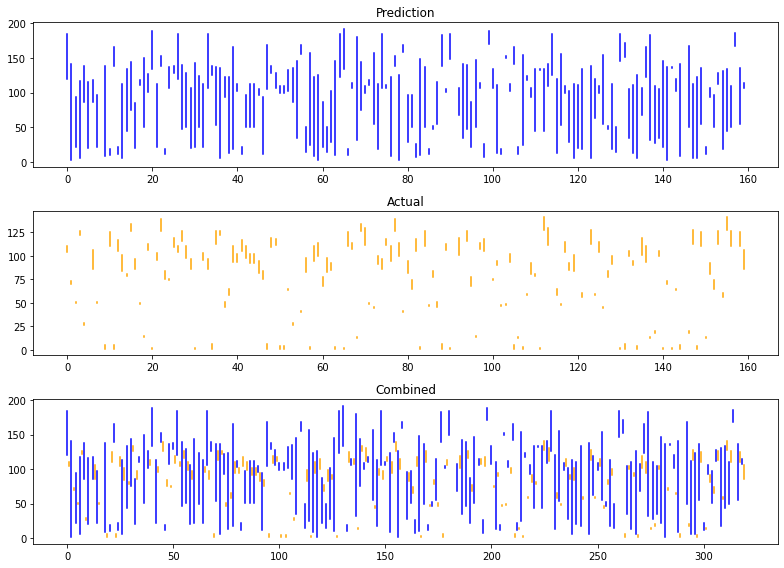

Elapsed time for eval 36.555896 seconds.
Elapsed time for eval 36.361030 seconds.


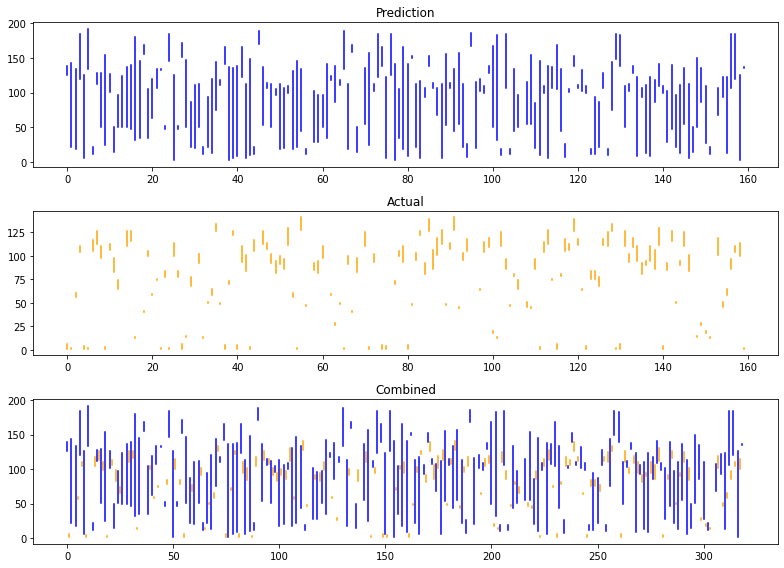

An allergy is an immune system response to a foreign substance that's not typically harmful to your body.They can include certain foods, pollen, or pet dander. Your immune system's job is to keep you healthy by fighting harmful pathogens.The name of disease is Allergy is an illness when you have  continuous_sneezing  shivering  chills  watering_from_eyes . You must apply calamine cover area with bandage use ice to compress itching .
What happend when my problem is  continuous_sneezing  shivering  chills  watering_from_eyes ? 


['What does it show when I have a problem as itching  skin_rash  nodal_skin_eruptions  dischromic _patches ? ',
 'What happend when my problem is itching  skin_rash  nodal_skin_eruptions  dischromic _patches ? ',
 'What can I do for Fungal infection ? ',
 'What do you advice for Fungal infection ? ',
 'What does it show when I have a problem as  continuous_sneezing  shivering  chills  watering_from_eyes ? ',
 'What happend when my problem is  continuous_sneezing  shivering  chills  watering_from_eyes ? ',
 'What can I do for Allergy ? ',
 'What do you advice for Allergy ? ',
 'What does it show when I have a problem as  stomach_pain  acidity  ulcers_on_tongue  vomiting  cough  chest_pain ? ',
 'What happend when my problem is  stomach_pain  acidity  ulcers_on_tongue  vomiting  cough  chest_pain ? ',
 'What can I do for GERD ? ',
 'What do you advice for GERD ? ',
 'What does it show when I have a problem as itching  vomiting  yellowish_skin  nausea  loss_of_appetite  abdominal_pain  ye

['In humans, fungal infections occur when an invading fungus takes over an area of the body and is too much for the immune system to handle. Fungi can live in the air, soil, water, and plants. There are also some fungi that live naturally in the human body. Like many microbes, there are helpful fungi and harmful fungi.The name of disease is Fungal infection is an illness when you have itching  skin_rash  nodal_skin_eruptions  dischromic _patches . You must bath twice use detol or neem in bathing water keep infected area dry use clean cloths .',
 'In humans, fungal infections occur when an invading fungus takes over an area of the body and is too much for the immune system to handle. Fungi can live in the air, soil, water, and plants. There are also some fungi that live naturally in the human body. Like many microbes, there are helpful fungi and harmful fungi.The name of disease is Fungal infection is an illness when you have itching  skin_rash  nodal_skin_eruptions  dischromic _patches

160

160

question What do you advice for Fungal infection ? 


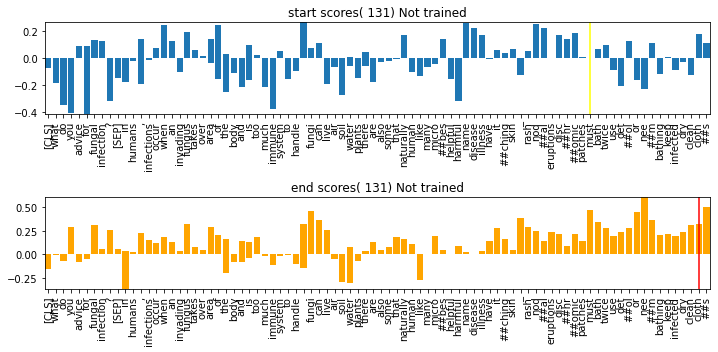


0 ) [CLS] 1 ) what 2 ) do 3 ) you 4 ) advice 5 ) for 6 ) fungal 7 ) infection 8 ) ? 9 ) [SEP] 
10 ) in 11 ) humans 12 ) , 13 ) fungal 14 ) infections 15 ) occur 16 ) when 17 ) an 18 ) invading 19 ) fungus 
20 ) takes 21 ) over 22 ) an 23 ) area 24 ) of 25 ) the 26 ) body 27 ) and 28 ) is 29 ) too 
30 ) much 31 ) for 32 ) the 33 ) immune 34 ) system 35 ) to 36 ) handle 37 ) . 38 ) fungi 39 ) can 
40 ) live 41 ) in 42 ) the 43 ) air 44 ) , 45 ) soil 46 ) , 47 ) water 48 ) , 49 ) and 
50 ) plants 51 ) . 52 ) there 53 ) are 54 ) also 55 ) some 56 ) fungi 57 ) that 58 ) live 59 ) naturally 
60 ) in 61 ) the 62 ) human 63 ) body 64 ) . 65 ) like 66 ) many 67 ) micro 68 ) ##bes 69 ) , 
70 ) there 71 ) are 72 ) helpful 73 ) fungi 74 ) and 75 ) harmful 76 ) fungi 77 ) . 78 ) the 79 ) name 
80 ) of 81 ) disease 82 ) is 83 ) fungal 84 ) infection 85 ) is 86 ) an 87 ) illness 88 ) when 89 ) you 
90 ) have 91 ) it 92 ) ##ching 93 ) skin 94 ) _ 95 ) rash 96 ) nod 97 ) ##al 98 ) _ 99 ) skin 
100 ) _

Elapsed time for training 107.048108 seconds.


question What do you advice for Fungal infection ? 
bath twice use detol or neem in bathing water keep infected area dry use clean cloths
use detol or neem in bathing water keep infected area dry use clean cloth

twice use detol or neem in bathing water keep infected area dry use clean



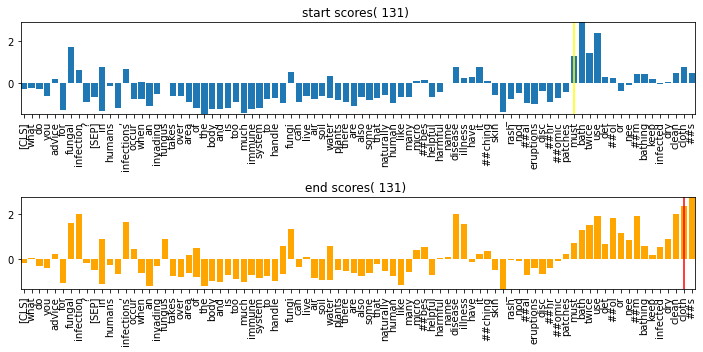

Elapsed time for eval 37.124625 seconds.
accuracy eval : 0.51875


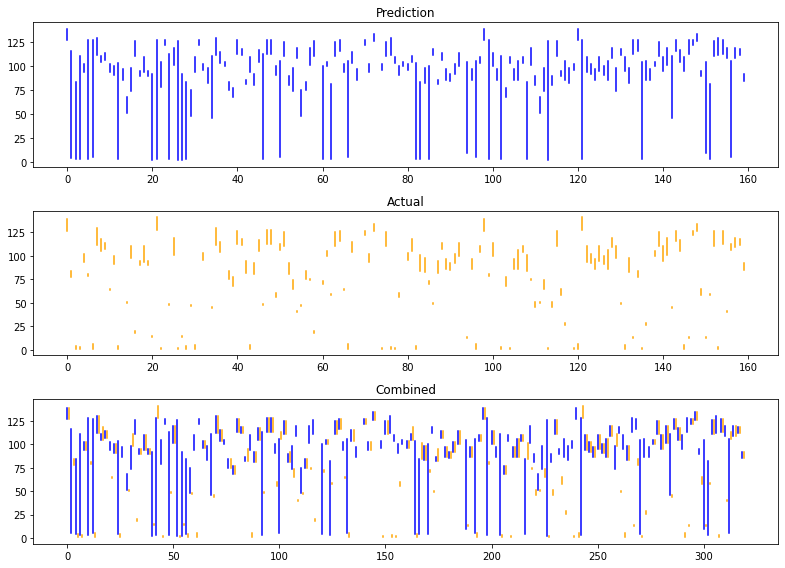

Elapsed time for training 108.934282 seconds.


Question What do you advice for Fungal infection ? 
bath twice use detol or neem in bathing water keep infected area dry use clean cloth
fungal infection is an illness when you have itching skin _ rash nodal _ skin _ eruptions dischromic _ patches. you must bath twice use detol or neem in bathing water keep infected area dry use clean cloths





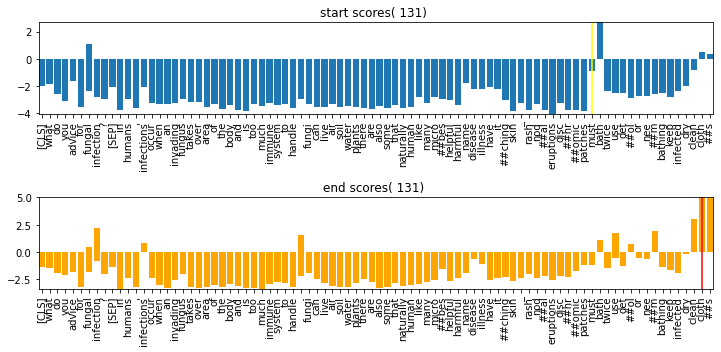

Elapsed time for eval 36.590785 seconds.
accuracy eval : 0.703125


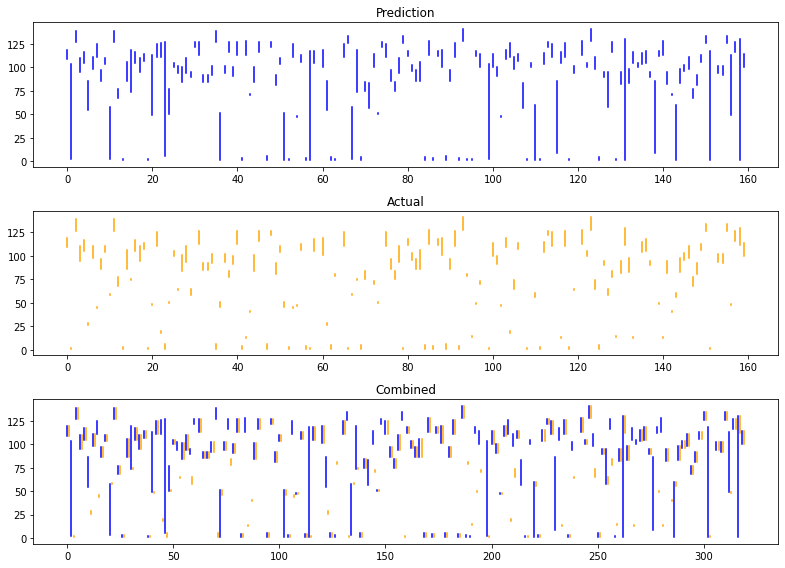

Elapsed time for training 107.048277 seconds.
Elapsed time for eval 34.702189 seconds.
accuracy eval : 0.940625


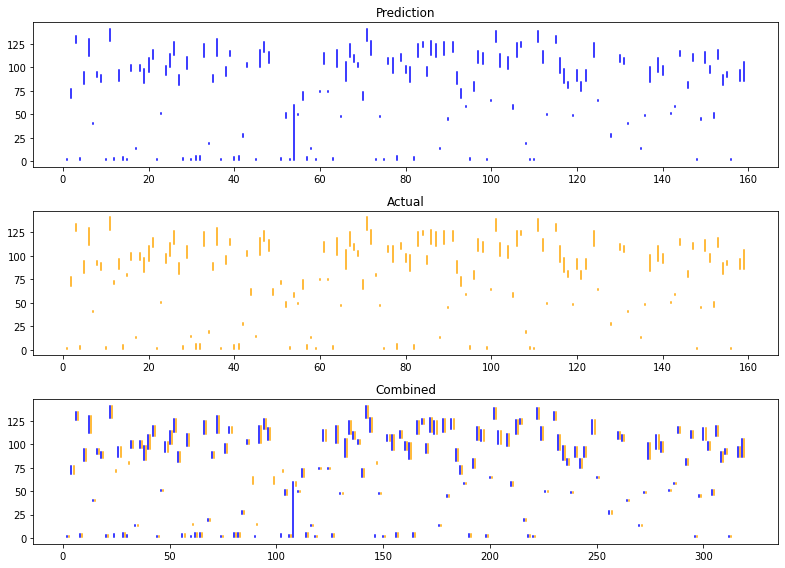

question What do you advice for Fungal infection ? 
bath twice use detol or neem in bathing water keep infected area dry use clean cloths


fungal infection is an illness when you have itching skin _ rash nodal _ skin _ eruptions dischromic _ patches. you must bath twice use detol
keep infected area dry use clean


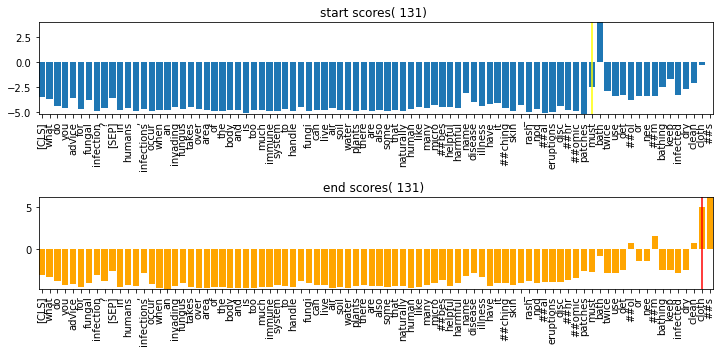

Elapsed time for training 103.381257 seconds.
Elapsed time for eval 34.176183 seconds.
accuracy eval : 0.95


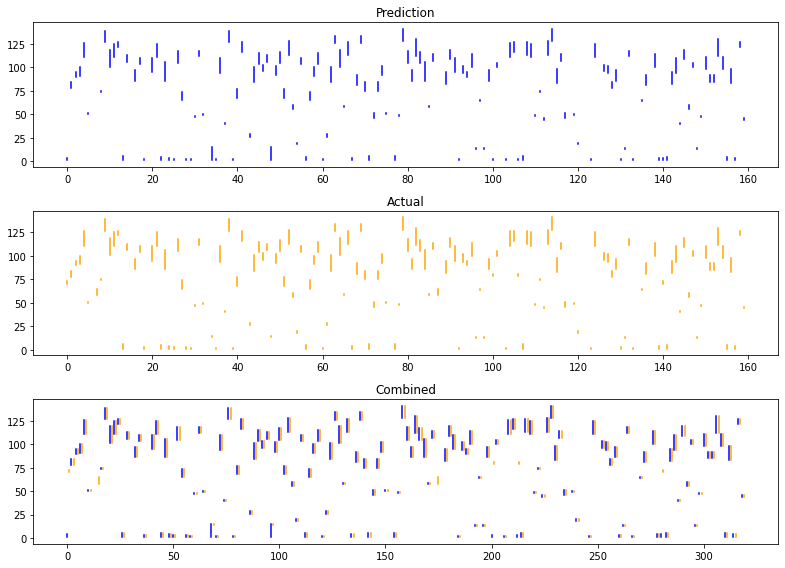

[110 128 127  83 121]
[128 127 117 114 126]


question What do you advice for Fungal infection ? 
bath twice use detol or neem in bathing water keep infected area dry use clean cloths
fungal infection is an illness when you have itching skin _ rash nodal _ skin _ eruptions dischromic _ patches. you must bath twice use detol or neem in bathing water keep infected area dry use clean cloth





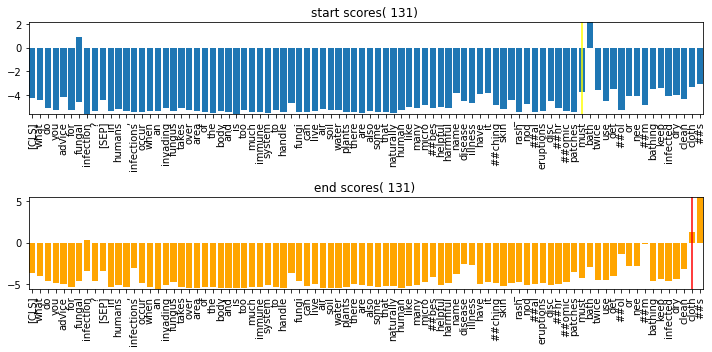



Step  1


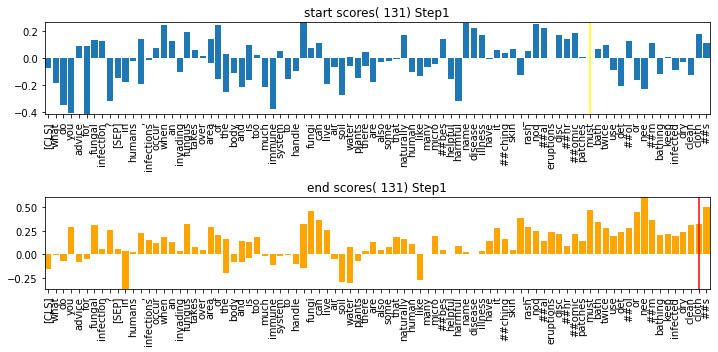



Step  2


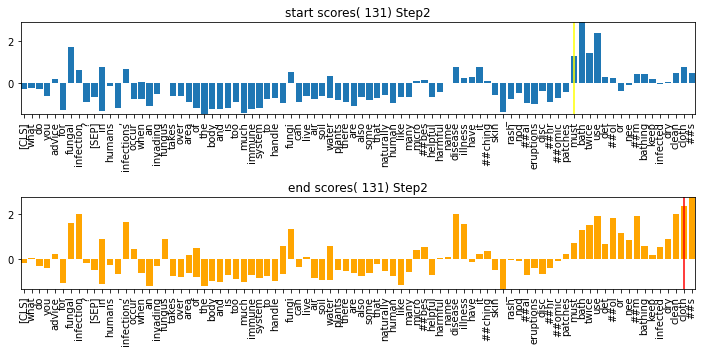



Step  3


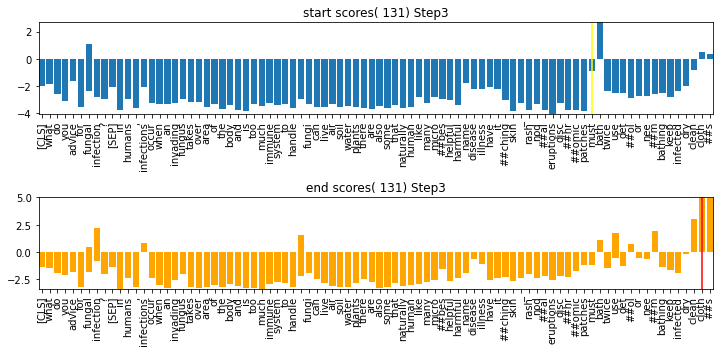



Step  4


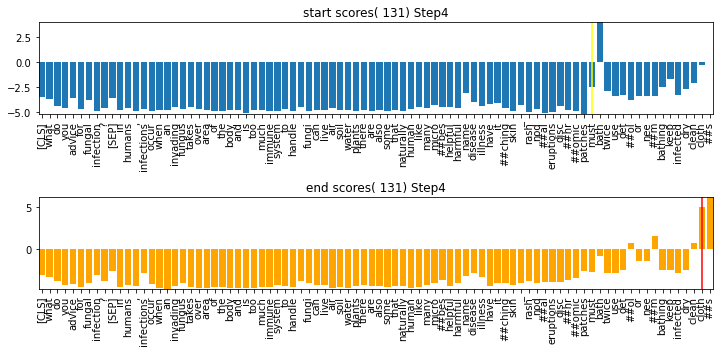



Step  5


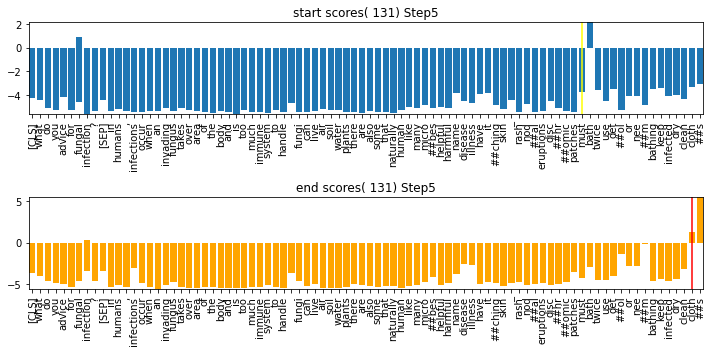

bath twice use detol or neem in bathing water keep infected area dry use clean cloths
fungal infection is an illness when you have itching skin _ rash nodal _ skin _ eruptions dischromic _ patches. you must bath twice use detol or neem in bathing water keep infected area dry use clean cloth



s [110  83 128 127 121]
e [128 127  84 117 114]
